In [1]:
!pip install ijson==3.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.1/113.1 kB 2.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import ijson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

In [4]:
def load_files_to_dfs(folder_path):
    # List to store the dataframes
    honda_dfs = []

    # Get all folders (assuming they are numbered and in the folder_path)
    for folder in os.listdir(folder_path):
        folder_num = folder  # Folder name (assuming it is the number)
        folder_full_path = os.path.join(folder_path, folder)

        if os.path.isdir(folder_full_path):
            # Look specifically for the 'insoles.csv' and 'labels.csv' file in each folder
            file_path_insoles = os.path.join(folder_full_path, 'insoles.csv')
            file_path_labels = os.path.join(folder_full_path, 'labels.csv')

            # making sure both paths exist prior to uploading df
            if os.path.exists(file_path_insoles):
                if os.path.exists(file_path_labels):
                    # Load the files into a DataFrames (assuming csv format)
                    df_insoles = pd.read_csv(file_path_insoles)
                    df_labels = pd.read_csv(file_path_labels)

                    # Merge the two DataFrames on the 'time', 'participant_id', 'task' column
                    df = pd.merge(df_insoles, df_labels, on=['time', 'participant_id', 'task'])

                    # Add participant_num column
                    df['participant_num'] = folder_num
                    print(folder_num)

                    # Add the DataFrame to the list
                    honda_dfs.append(df)

    return honda_dfs

# Usage example
folder_path = '/content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/data_set/courseB'  # Replace with the path to the main directory containing folders
dataframes = load_files_to_dfs(folder_path)

# # Print the dataframes list
# for idx, df in enumerate(dataframes):
#     print(f"DataFrame from folder {idx + 1}:\n", df.head())


id15
id01
id12
id14
id24
id23
id08
id07
id25
id22
id19
id02
id04
id10
id16
id18
id17
id05
id13
id03


In [5]:
len(dataframes)

20

In [6]:
dataframes_copy = dataframes

In [7]:
#list all the columns
# list(dataframes[0].columns)

In [8]:
dataframes[0]['walk_mode'].unique()

array(['walk', 'slope_down', 'slope_up', 'stairs_up'], dtype=object)

In [9]:
dataframes[0]

,Unnamed: 0,time,participant_id,task,Left_Hallux,Left_Toes,Left_Met1,Left_Met3,Left_Met5,Left_Arch,...,insoles_RightFoot_time_to_lift,xsens_footContacts_LeftFoot_Heel,xsens_footContacts_LeftFoot_Toe,xsens_footContacts_RightFoot_Heel,xsens_footContacts_RightFoot_Toe,walk_orientation,walk_interaction,walk_mode_id,walk_orientation_id,participant_num
0,0,0,15,B,4.0,0.0,6.0,232.0,315.0,666.0,...,866.0,False,False,True,False,straight,no,8,1,id15
1,1,16,15,B,1.0,0.0,3.0,228.0,322.0,666.0,...,850.0,False,False,True,False,straight,no,8,1,id15
2,2,33,15,B,1.0,1.0,1.0,233.0,317.0,660.0,...,833.0,False,False,True,False,straight,no,8,1,id15
3,3,50,15,B,0.0,4.0,1.0,233.0,313.0,666.0,...,816.0,False,False,True,False,straight,no,8,1,id15
4,4,66,15,B,5.0,4.0,1.0,230.0,320.0,666.0,...,800.0,False,False,True,False,straight,no,8,1,id15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34755,34755,579250,15,B,307.0,3.0,0.0,271.0,232.0,0.0,...,-1.0,False,False,True,False,straight,no,8,17,id15
34756,34756,579266,15,B,246.0,4.0,1.0,259.0,229.0,2.0,...,-1.0,False,False,True,False,straight,no,8,17,id15
34757,34757,579283,15,B,206.0,1.0,1.0,239.0,139.0,0.0,...,-1.0,False,False,True,False,straight,no,8,17,id15
34758,34758,579300,15,B,1.0,1.0,1.0,139.0,103.0,1.0,...,-1.0,False,False,False,False,straight,no,8,17,id15


In [10]:
sensor_types = ['Acc','Mag','Gyr']

leg = ['Left', 'Right']

sensor_locations = ['Hallux', 'Toes', 'Met1', 'Met3', 'Met5', 'Arch', 'Heel_R', 'Heel_L']

axes = ['x', 'y', 'z', 'raw', 'norm']

columns = ['Unnamed: 0', 'time', 'participant_id', 'task', 'Left_Hallux', 'Left_Toes', 'Left_Met1',
           'Left_Met3', 'Left_Met5', 'Left_Arch', 'Left_Heel_R', 'Left_Heel_L', 'Left_Acc_x', 'Left_Acc_y', 'Left_Acc_z',
           'Left_Gyr_x', 'Left_Gyr_y', 'Left_Gyr_z', 'Left_Mag_x', 'Left_Mag_y', 'Left_Mag_z', 'Left_Temp', 'Right_Hallux',
           'Right_Toes', 'Right_Met1', 'Right_Met3', 'Right_Met5', 'Right_Arch', 'Right_Heel_L', 'Right_Heel_R', 'Right_Acc_x',
           'Right_Acc_y', 'Right_Acc_z', 'Right_Gyr_x', 'Right_Gyr_y', 'Right_Gyr_z', 'Right_Mag_x', 'Right_Mag_y', 'Right_Mag_z',
           'Right_Temp', 'Right_Toes_raw', 'Right_Hallux_raw', 'Right_Met5_raw', 'Right_Met3_raw', 'Right_Met1_raw', 'Right_Arch_raw', 'Right_Heel_R_raw',
           'Right_Heel_L_raw', 'Left_Toes_raw', 'Left_Hallux_raw', 'Left_Met5_raw', 'Left_Met3_raw', 'Left_Met1_raw', 'Left_Arch_raw', 'Left_Heel_R_raw',
           'Left_Heel_L_raw', 'Right_Acc_x_raw', 'Right_Acc_y_raw', 'Right_Acc_z_raw', 'Right_Mag_x_raw', 'Right_Mag_y_raw', 'Right_Mag_z_raw', 'Right_Gyr_x_raw',
           'Right_Gyr_y_raw', 'Right_Gyr_z_raw', 'Left_Acc_x_raw', 'Left_Acc_y_raw', 'Left_Acc_z_raw', 'Left_Mag_x_raw', 'Left_Mag_z_raw', 'Left_Gyr_x_raw',
           'Left_Gyr_y_raw', 'Left_Gyr_z_raw', 'Left_Hallux_norm', 'Left_Toes_norm', 'Left_Met1_norm', 'Left_Met3_norm', 'Left_Met5_norm', 'Left_Arch_norm',
           'Left_Heel_R_norm', 'Left_Heel_L_norm', 'Right_Hallux_norm', 'Right_Toes_norm', 'Right_Met1_norm', 'Right_Met3_norm', 'Right_Met5_norm', 'Right_Arch_norm',
           'Right_Heel_L_norm', 'Right_Heel_R_norm', 'Left_Max_Pressure_norm', 'Right_Max_Pressure_norm', 'walk_mode', 'repetition', 'insoles_RightFoot_is_step',
           'insoles_LeftFoot_is_step', 'insoles_RightFoot_is_lifted', 'insoles_LeftFoot_is_lifted', 'insoles_LeftFoot_on_ground',
           'insoles_RightFoot_on_ground', 'insoles_LeftFoot_time_to_step', 'insoles_LeftFoot_time_to_lift', 'insoles_RightFoot_time_to_step',
           'insoles_RightFoot_time_to_lift', 'xsens_footContacts_LeftFoot_Heel', 'xsens_footContacts_LeftFoot_Toe', 'xsens_footContacts_RightFoot_Heel',
           'xsens_footContacts_RightFoot_Toe', 'walk_orientation', 'walk_interaction', 'walk_mode_id', 'walk_orientation_id', 'participant_num']


In [11]:
# get the 5 types of surfaces/actions done in this dataset
walk_modes = dataframes_copy[0]['walk_mode'].unique()

# create a subset dataframe for each of the types
subset_dfs = {}
for walk_mode in walk_modes:
  for df in dataframes_copy:
      identifier = walk_mode + '_' + df['participant_num'].iloc[0]
      if identifier not in subset_dfs:
          subset_dfs[identifier] = df[df['walk_mode'] == walk_mode]


In [12]:
# change the column names wiht no suffix to have

In [13]:
# subset_dfs['slope_up_id12']

In [14]:
extras_df = []

for key, df in subset_dfs.items():
    df.columns = columns
    # keep only listed columns
    df = df[['Unnamed: 0', 'time', 'participant_id', 'task','Left_Max_Pressure_norm', 'Right_Max_Pressure_norm', 'walk_mode', 'repetition', 'insoles_RightFoot_is_step',
           'insoles_LeftFoot_is_step', 'insoles_RightFoot_is_lifted', 'insoles_LeftFoot_is_lifted', 'insoles_LeftFoot_on_ground',
           'insoles_RightFoot_on_ground', 'insoles_LeftFoot_time_to_step', 'insoles_LeftFoot_time_to_lift', 'insoles_RightFoot_time_to_step',
           'insoles_RightFoot_time_to_lift', 'xsens_footContacts_LeftFoot_Heel', 'xsens_footContacts_LeftFoot_Toe', 'xsens_footContacts_RightFoot_Heel',
           'xsens_footContacts_RightFoot_Toe', 'walk_orientation', 'walk_interaction']]

    extras_df.append(df)

# Concatenate all trials into a single DataFrame
all_foot_sensor_extras_df = pd.concat(extras_df, ignore_index=True)

In [15]:
all_foot_sensor_extras_df

,Unnamed: 0,time,participant_id,task,Left_Max_Pressure_norm,Right_Max_Pressure_norm,walk_mode,repetition,insoles_RightFoot_is_step,insoles_LeftFoot_is_step,...,insoles_LeftFoot_time_to_step,insoles_LeftFoot_time_to_lift,insoles_RightFoot_time_to_step,insoles_RightFoot_time_to_lift,xsens_footContacts_LeftFoot_Heel,xsens_footContacts_LeftFoot_Toe,xsens_footContacts_RightFoot_Heel,xsens_footContacts_RightFoot_Toe,walk_orientation,walk_interaction
0,0,0,15,B,0.804886,0.310507,walk,1,True,True,...,0.0,183.0,0.0,866.0,False,False,True,False,straight,no
1,1,16,15,B,0.748893,0.596743,walk,1,False,False,...,684.0,167.0,1300.0,850.0,False,False,True,False,straight,no
2,2,33,15,B,0.672273,0.675680,walk,1,False,False,...,667.0,150.0,1283.0,833.0,False,False,True,False,straight,no
3,3,50,15,B,0.668793,0.693511,walk,1,False,False,...,650.0,133.0,1266.0,816.0,False,False,True,False,straight,no
4,4,66,15,B,0.652833,0.705888,walk,1,False,False,...,634.0,117.0,1250.0,800.0,False,False,True,False,straight,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
711465,34651,577516,3,B,0.918084,0.151711,stairs_up,3,False,False,...,700.0,167.0,184.0,834.0,False,False,False,False,straight,no
711466,34652,577533,3,B,0.933938,0.121522,stairs_up,3,False,False,...,683.0,150.0,167.0,817.0,False,True,False,False,straight,no
711467,34653,577550,3,B,0.922189,0.145855,stairs_up,3,False,False,...,666.0,133.0,150.0,800.0,False,True,False,False,straight,no
711468,34654,577566,3,B,0.879081,0.193779,stairs_up,3,False,False,...,650.0,117.0,134.0,784.0,False,False,False,False,straight,no


In [16]:
import pandas as pd

# Define your list of sensor locations
sensor_locations = ['Hallux', 'Toes', 'Met1', 'Met3', 'Met5', 'Arch', 'Heel_R', 'Heel_L']

# Function to extract the sensor location from a column name based on the sensor_locations list
def extract_sensor_location(column_name):
    for location in sensor_locations:
        if location in column_name:
            return location
    return None

# Function to remove the sensor location from a column name
def remove_sensor_location(column_name):
    for location in sensor_locations:
        if location in column_name:
            return column_name.replace(location, '').strip('_')
    return column_name

# Initialize a list to hold DataFrames for all trials
all_trials_df_list = []

# Loop over each DataFrame in subset_dfs (assuming it's a dictionary of trial DataFrames)
for key, trial_df in subset_dfs.items():
    df_list = []
    surface_type = key.split('_')
    if len(surface_type) > 2:
        surface_type = ' '.join(surface_type[:2])
    else:
        surface_type = surface_type[0]

    # For each sensor, collect relevant columns and create a new DataFrame
    for sensor_location in sensor_locations:
        # Find all columns related to this sensor location
        sensor_columns = [col for col in trial_df.columns if sensor_location in col]

        if sensor_columns:
            # Create a new DataFrame for this sensor
            df_by_sensor = pd.DataFrame({
                "time": trial_df["time"],
                "participant_id": trial_df["participant_id"],
                "task": trial_df["task"],
                "surface_type": surface_type,
                "sensor_location": sensor_location
            })

            # For each sensor-related column, add it to the new DataFrame
            for col in sensor_columns:
                new_column_name = remove_sensor_location(col)
                df_by_sensor[new_column_name] = trial_df[col]

            # Append the sensor DataFrame to the list
            df_list.append(df_by_sensor)

    # Concatenate all DataFrames for this trial and add to the main list if any were created
    if df_list:
        trial_df_combined = pd.concat(df_list)
        all_trials_df_list.append(trial_df_combined)

        print(f"Processed {key}")
    else:
        print(f"No valid sensor columns to process for {key}")

# Concatenate all trials into a single DataFrame
all_foot_sensors_df = pd.concat(all_trials_df_list, ignore_index=True)

# Uncomment to export the final combined DataFrame to CSV
# final_combined_df.to_csv('/path/to/final_output.csv', index=False)



Processed walk_id15
Processed walk_id01
Processed walk_id12
Processed walk_id14
Processed walk_id24
Processed walk_id23
Processed walk_id08
Processed walk_id07
Processed walk_id25
Processed walk_id22
Processed walk_id19
Processed walk_id02
Processed walk_id04
Processed walk_id10
Processed walk_id16
Processed walk_id18
Processed walk_id17
Processed walk_id05
Processed walk_id13
Processed walk_id03
Processed slope_down_id15
Processed slope_down_id01
Processed slope_down_id12
Processed slope_down_id14
Processed slope_down_id24
Processed slope_down_id23
Processed slope_down_id08
Processed slope_down_id07
Processed slope_down_id25
Processed slope_down_id22
Processed slope_down_id19
Processed slope_down_id02
Processed slope_down_id04
Processed slope_down_id10
Processed slope_down_id16
Processed slope_down_id18
Processed slope_down_id17
Processed slope_down_id05
Processed slope_down_id13
Processed slope_down_id03
Processed slope_up_id15
Processed slope_up_id01
Processed slope_up_id12
Processe

In [17]:
all_foot_sensors_df

,time,participant_id,task,surface_type,sensor_location,Left,Right,Right__raw,Left__raw,Left__norm,Right__norm
0,0,15,B,walk,Hallux,4.0,0.0,4094.584887,3400.962218,0.504274,0.000257
1,16,15,B,walk,Hallux,1.0,4.0,4094.125613,3351.939647,0.553982,0.000360
2,33,15,B,walk,Hallux,1.0,0.0,4091.917566,3320.376349,0.587162,0.001906
3,50,15,B,walk,Hallux,0.0,0.0,4091.895976,3310.167812,0.598013,0.001735
4,66,15,B,walk,Hallux,5.0,1.0,4093.874877,3303.437439,0.605036,0.000464
...,...,...,...,...,...,...,...,...,...,...,...
5691755,577516,3,B,stairs up,Heel_L,219.0,0.0,4095.000000,4091.120750,0.001316,0.000000
5691756,577533,3,B,stairs up,Heel_L,209.0,1.0,4092.275035,4094.091678,0.000208,0.001235
5691757,577550,3,B,stairs up,Heel_L,197.0,0.0,4093.725430,4092.575143,0.000651,0.000578
5691758,577566,3,B,stairs up,Heel_L,114.0,0.0,3774.555796,4094.120982,0.000402,0.193779


In [18]:
plot_8 = all_foot_sensors_df[all_foot_sensors_df['participant_id'] == 8].sort_values(by='time')

In [19]:
# plot_8_Hallux = all_foot_sensors_df[all_foot_sensors_df['participant_id'] == 8] & all_foot_sensors_df[all_foot_sensors_df['sensor_location'] == 'Hallux']

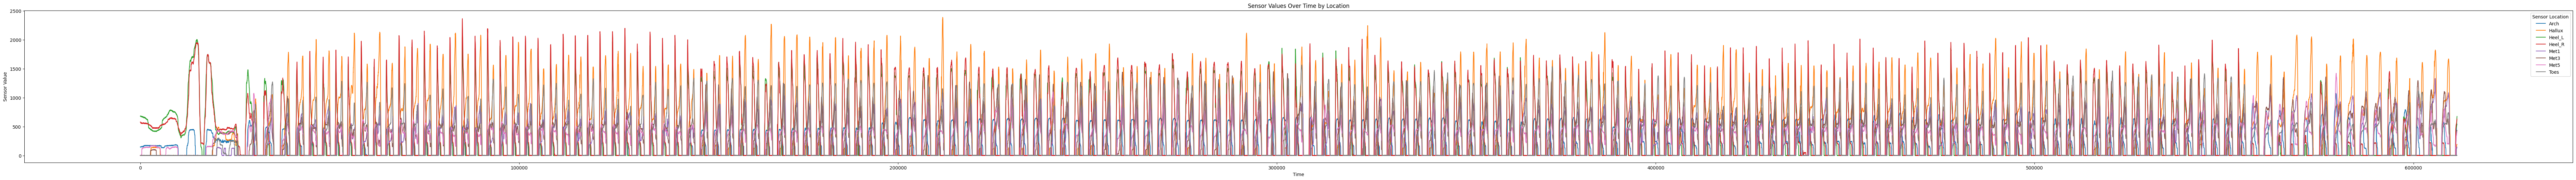

In [20]:
import matplotlib.pyplot as plt

# Group by sensor location and plot each group separately
plt.figure(figsize=(100, 6))

for sensor_location, group_df in plot_8.groupby('sensor_location'):
    plt.plot(group_df['time'], group_df['Left'], label=sensor_location)

# Add labels, title, and legend
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.title('Sensor Values Over Time by Location')
plt.legend(title='Sensor Location')
plt.show()



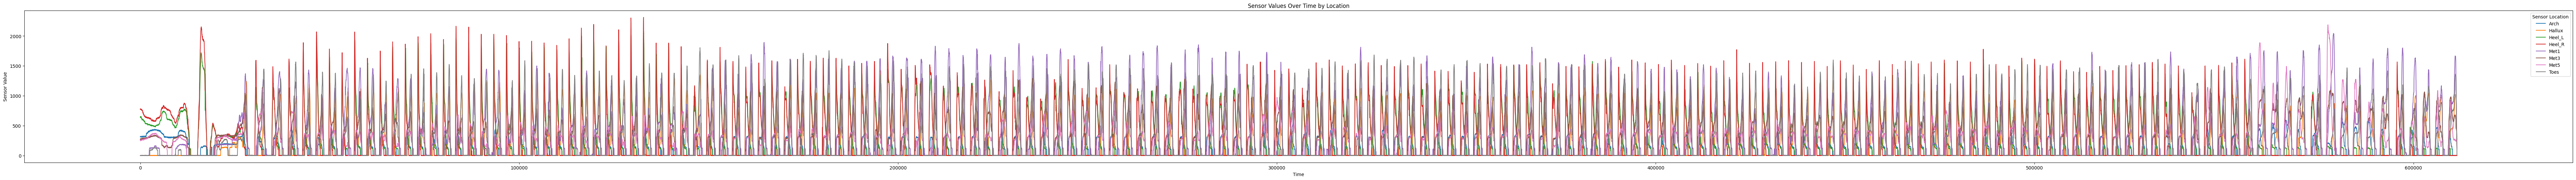

In [21]:
import matplotlib.pyplot as plt

# Group by sensor location and plot each group separately
plt.figure(figsize=(100, 6))

for sensor_location, group_df in plot_8.groupby('sensor_location'):
    plt.plot(group_df['time'], group_df['Right'], label=sensor_location)

# Add labels, title, and legend
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.title('Sensor Values Over Time by Location')
plt.legend(title='Sensor Location')
plt.show()



In [24]:
# export csv to folder
all_foot_sensors_df.to_csv('/content/drive/MyDrive/Next_Step/Honda_Participants/CourseB/foot_pressure_data/all_foot_sensors_df.csv', index=False)

In [25]:
# export csv to folder
all_foot_sensor_extras_df.to_csv('/content/drive/MyDrive/Next_Step/Honda_Participants/CourseB/foot_pressure_data/all_foot_sensor_extras_df.csv', index=False)